<a href="https://colab.research.google.com/github/np2868/DS-project/blob/main/FinalProject_MinFC_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



Can you predict the level of problematic internet usage exhibited by children and adolescents, based on their physical activity? The goal of this competition is to develop a predictive model that analyzes children's physical activity and fitness data to identify early signs of problematic internet use. Identifying these patterns can help trigger interventions to encourage healthier digital habits.

* https://www.kaggle.com/competitions/child-mind-institute-problematic-internet-use/data

By submitting this project, I accept responsibility for my role in ensuring the integrity of the work submitted by the group in which I participated.

## EDA, data cleaning and feature engineering
* `X_train`, `X_test`, `y_train`, and `y_test` has been provided.
* You all have 986 rows to start in the dataset (the rows in train.csv that have a corresponding parquet file - there are 996 parquet files but 10 are empty, so we will just use the 986 with at least SOME data.)
* Explore the data and clean it up as you see fit - make sure you `fit_transform()` on the training data and `transform()` on the test data.
* It is up to you whether or not you want to curate the training dataset to get a better fit on the test dataset (for example, if you would like to use some sampling strategy like SMOTE, that's great - just remember that you DON'T change the distribution of the target variable in the test partition.)

## Modeling
* You may perform your modeling in a different notebook (to be submitted as an appendix), but you must run your final and BEST model here and all output must be displayed.
  * It's up to you to decide what the best pre-processing steps should be!

## Model Results
* Classification report and confusion report for train and test partition.
  * You may use cross-validation to help pick the optimal hyperparameters for your model.
  * You may change the classification threshold from 0.5 to anything else that improves your score.
* Verify your shape of the train and test partitions to ensure there is no data leakage!
* You are being graded on the best weighted F1 score
  * https://scikit-learn.org/1.5/modules/generated/sklearn.metrics.f1_score.html (it can be read from the bottom right of the classification report)

## Interpretability and Discussion
* Create permutation importance for top five variables
* Create partial dependence plots for top five variables
  * Don't forget about the `num_grid_points` argument to your PDP if it takes a long time to make the plot.
* You SHOULD add other tables/plots/analyses to help tell your story! Why is your model predicting the way it does? What things did you try to capture in your model? Did you use a simpler set of predictors or just use the whole kitchen sink?
  * You really have to dig into what they think are driving their model predictions.
* provide a business recommendation based on the results of your model - what do we think is causing problem internet usage! Do we need the detailed time series data? Or do we just need demographic data? We will take off substantial points if there is not a well-written and cohesive presentation of results.

## 🛷 Sliding grading scale
* I expect everything in this notebook to be of sufficient quality - well-organized with lots of comments and cleaned up nice for presentation to management. I will deduct substantial points if this is just my code copy/pasted without any deep analysis.
* Your 'starting grades' will range from an 70 to a 100 based on model weifhted F1 score for the TEST PARTITION (you can use the `weighted F1 score` function from sci-kit learn to evaluate the final model.)
  * https://scikit-learn.org/1.5/modules/generated/sklearn.metrics.f1_score.html
* Of course, if something is missing from the above rubric, we will deduct points from your starting grade.
  * If you came in first place and lost 10 points somewhere, your final grade is 100 - 10 = 90
  * If you came in last place (for accuracy) and lost 10 points somewhere, your final grade is 80 - 10 = 70.


# Import Modules

In [ ]:
# Install required libraries
!pip install gdown pandas tsfresh tensorflow scikeras[tensorflow] matplotlib seaborn --quiet


In [ ]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_auc_score
from tsfresh.feature_selection import select_features
from tsfresh.utilities.dataframe_functions import impute
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.backend import clear_session

# Mount Drive and Load Data

In [ ]:
# Step 1: Define Google Drive File IDs and Filenames
file_id_to_filename = {
    "1-3KuajcxhPwXQIv24ptXOVkwLQGTonl-": "MIN_FC.csv",
    "1-F27X3CJC9xi6KNeW4n0p7w97hgn46XN": "train.csv",
    "1R7NjVu1piDhCt1T6oFFDb21U8z-W0vfV": "X_test_F24_withID.csv",
    "1-D30G73cLD8zkBQ5Txpf3DHaNHNjJcXq": "X_train_F24_withID.csv",
    "1-3ra9gHnuRwggv5stgelEL_FuS7MToRS": "y_test_F24_withID.csv",
    "1-5SWLgPmxJw_3Sc_fvPYs3MZUXQOfNyn": "y_train_F24_withID.csv",
    "1-1fIh1mg-Bx--f4Q_KcG0H9acqJFY9RL": "EFFICIENT_FC_df.csv"
}

# Step 2: Download Files from Google Drive
import gdown

save_dir = "/content"  # Save files to Colab's working directory
os.makedirs(save_dir, exist_ok=True)

for file_id, filename in file_id_to_filename.items():
    url = f"https://drive.google.com/uc?id={file_id}"
    output_path = os.path.join(save_dir, filename)
    print(f"Downloading {filename}...")
    gdown.download(url, output_path, quiet=False)

# Step 3: Verify Files Have Been Downloaded
downloaded_files = os.listdir(save_dir)
print("\nDownloaded files:", downloaded_files)

# Step 4: Load the Datasets
files_to_load = [os.path.join(save_dir, filename) for filename in file_id_to_filename.values()]
dataframes = {}

for file in files_to_load:
    try:
        file_key = os.path.basename(file).split('.')[0]  # Use filename without extension as the key
        dataframes[file_key] = pd.read_csv(file)
        print(f"Successfully loaded {file}")
    except Exception as e:
        print(f"Error loading {file}: {e}")


Downloading...
From: https://drive.google.com/uc?id=1-3KuajcxhPwXQIv24ptXOVkwLQGTonl-
To: /content/MIN_FC.csv
100%|██████████| 1.93M/1.93M [00:00<00:00, 63.0MB/s]


Downloading...
From: https://drive.google.com/uc?id=1-F27X3CJC9xi6KNeW4n0p7w97hgn46XN
To: /content/train.csv
100%|██████████| 1.15M/1.15M [00:00<00:00, 29.4MB/s]


Downloading...
From: https://drive.google.com/uc?id=1R7NjVu1piDhCt1T6oFFDb21U8z-W0vfV
To: /content/X_test_F24_withID.csv
100%|██████████| 45.9k/45.9k [00:00<00:00, 57.5MB/s]


Downloading...
From: https://drive.google.com/uc?id=1-D30G73cLD8zkBQ5Txpf3DHaNHNjJcXq
To: /content/X_train_F24_withID.csv
100%|██████████| 183k/183k [00:00<00:00, 13.5MB/s]


Downloading...
From: https://drive.google.com/uc?id=1-3ra9gHnuRwggv5stgelEL_FuS7MToRS
To: /content/y_test_F24_withID.csv
100%|██████████| 5.64k/5.64k [00:00<00:00, 12.4MB/s]


Downloading...
From: https://drive.google.com/uc?id=1-5SWLgPmxJw_3Sc_fvPYs3MZUXQOfNyn
To: /content/y_train_F24_withID.csv
100%|██████████| 22.4k/22.4k [00:00<00:00, 31.3MB/s]


Downloading...
From (original): https://drive.google.com/uc?id=1-1fIh1mg-Bx--f4Q_KcG0H9acqJFY9RL
From (redirected): https://drive.google.com/uc?id=1-1fIh1mg-Bx--f4Q_KcG0H9acqJFY9RL&confirm=t&uuid=fd60e3cb-72d7-47c2-9073-c5e2977e36e9
To: /content/EFFICIENT_FC_df.csv
100%|██████████| 174M/174M [00:00<00:00, 181MB/s]



Downloaded files: ['.config', 'X_test_F24_withID.csv', 'EFFICIENT_FC_df.csv', 'train.csv', 'X_train_F24_withID.csv', 'my_dir', 'y_train_F24_withID.csv', 'y_test_F24_withID.csv', 'MIN_FC.csv', 'sample_data']
Successfully loaded /content/MIN_FC.csv
Successfully loaded /content/train.csv
Successfully loaded /content/X_test_F24_withID.csv
Successfully loaded /content/X_train_F24_withID.csv
Successfully loaded /content/y_test_F24_withID.csv
Successfully loaded /content/y_train_F24_withID.csv
Successfully loaded /content/EFFICIENT_FC_df.csv


## Business Problem

> "The business objective is to determine which biological markers will improve the diagnosis and treatment of mental health and learning disorders from an objective biological perspective.  
> Two elements of this study are being used for this competition: physical activity data (wrist-worn accelerometer data, fitness assessments, and questionnaires) and internet usage behavior data. The goal of this competition is to predict from this data a participant's Severity Impairment Index (SII), a standard measure of problematic internet use."

Our initial insights suggested a direct correlation between the participant's physical activity level and their respective internet usage. We hypothesized that individuals with higher weight and BMI are likely to spend more time using the internet because they may engage less frequently in physical activities such as cardiovascular exercise or strength training.

Additionally, we considered the mental health implications of increased screen time. Research has consistently shown correlations between prolonged screen exposure and mental health challenges such as anxiety and depression.

Through this project, our team aims to uncover actionable insights and best practices for raising and educating youth to foster healthy lifestyles and reduce health and psychological challenges, both now and in the future.



## Explaination of Data Sources

We were given pre-split data to maintain consistency across the groups in our class, specifically split IDs for training and testing. Our task involved merging the IDs from the demographic dataset with the time-series data to ensure we used the correct data for each participant.


  **Demographic and Time Series**


  * **train_df:**
A dataset containing raw demographic data with a total of 3,960 rows. This serves as the base demographic dataset.

  * **X_train_df**:
The raw time series data subset used for model training. This dataset is part of the train partition and includes entries where the ID is present in the time series data. It also incorporates mean values for features.

  * **X_test_df:**
The raw time series data subset used for model testing. Similar to X_train_df, this dataset is part of the test partition and includes entries where the ID is present in the time series data, along with mean values for features.

  * **Y_train_df:**
The raw time series data used for training the model. This dataset contains IDs and their corresponding SII

  * **Y_test_df:**
The raw time series data used for testing the model. Similar to Y_train_df, it includes IDs and their corresponding SII values for the test partition.

**Feature Engineering of Time Series Data**

**Ts Fresh:** This is the feature engineering step applied to time series variables. It generates features that describe the time series data, helping to extract meaningful patterns.

  * **MIN_FC:**
Features generated for all time steps in the time series data. This includes a limited (small) subset of features.

  * **SOME_FC:**
A subset of efficient feature computation (FC) parameters applied to the downsampled time series data. This subset is selectively curated for efficiency.

  * **EFFICIENT_FC:**
Another subset of efficient FC parameters, similar to SOME_FC, designed to enhance performance on the downsampled time series data.


In [ ]:
# Step 5: Extract DataFrames
train_df = dataframes['train']
X_train_df = dataframes['X_train_F24_withID']
X_test_df = dataframes['X_test_F24_withID']
y_train_df = dataframes['y_train_F24_withID']
y_test_df = dataframes['y_test_F24_withID']
Min_FC_df = dataframes['MIN_FC']
Efficient_FC_df = dataframes['EFFICIENT_FC_df']

# Verify Shapes of Loaded DataFrames
print(f"train_df shape: {train_df.shape}")
print(f"X_train_df shape: {X_train_df.shape}")
print(f"X_test_df shape: {X_test_df.shape}")
print(f"y_train_df shape: {y_train_df.shape}")
print(f"y_test_df shape: {y_test_df.shape}")
print(f"Min_FC_df shape: {Min_FC_df.shape}")
print(f"Efficient_FC_df shape: {Efficient_FC_df.shape}")

train_df shape: (3960, 82)
X_train_df shape: (796, 15)
X_test_df shape: (200, 15)
y_train_df shape: (797, 3)
y_test_df shape: (201, 3)
Min_FC_df shape: (996, 141)
Efficient_FC_df shape: (995, 10879)


# Cleaning and Preparing the Data

In [ ]:
# Step 6: Drop unnecessary columns and set 'id' as index
for df in [X_train_df, X_test_df, y_train_df, y_test_df, train_df, Min_FC_df]:
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)
    if 'id' in df.columns:
        df.set_index('id', inplace=True)

# Verify the cleanup
print("\nDataFrames after cleanup:")
print(f"X_train_df shape: {X_train_df.shape}, index: {X_train_df.index.name}")
print(f"X_test_df shape: {X_test_df.shape}, index: {X_test_df.index.name}")
print(f"y_train_df shape: {y_train_df.shape}, index: {y_train_df.index.name}")
print(f"y_test_df shape: {y_test_df.shape}, index: {y_test_df.index.name}")
print(f"Min_FC_df shape: {Min_FC_df.shape}, index: {Min_FC_df.index.name}")
print(f"train_df shape: {train_df.shape}, index: {train_df.index.name}")




DataFrames after cleanup:
X_train_df shape: (796, 13), index: id
X_test_df shape: (200, 13), index: id
y_train_df shape: (797, 1), index: id
y_test_df shape: (201, 1), index: id
Min_FC_df shape: (996, 140), index: id
train_df shape: (3960, 81), index: id


Given the inital dataset has 3,960 rows, and the data was reduced to 996 to align with the amount of uncorrupted parquet files, the next step shows that we are going to align the train_df to the X_train_df so that the 'id' fields align.

In [ ]:
# Step 7: Verify the consistency of IDs
common_train_ids = X_train_df.index.intersection(y_train_df.index).intersection(Min_FC_df.index)
common_test_ids = X_test_df.index.intersection(y_test_df.index).intersection(Min_FC_df.index)

print("\nValidation of IDs:")
print(f"Number of overlapping Train IDs: {len(common_train_ids)}")
print(f"Number of overlapping Test IDs: {len(common_test_ids)}")

# Display some sample IDs for manual verification
print("\nSample IDs in Train:")
print(f"X_train_df: {X_train_df.index[:5].tolist()}")
print(f"y_train_df: {y_train_df.index[:5].tolist()}")
print(f"Min_FC_df: {Min_FC_df.index[:5].tolist()}")

print("\nSample IDs in Test:")
print(f"X_test_df: {X_test_df.index[:5].tolist()}")
print(f"y_test_df: {y_test_df.index[:5].tolist()}")



Validation of IDs:
Number of overlapping Train IDs: 796
Number of overlapping Test IDs: 200

Sample IDs in Train:
X_train_df: ['a0522c83', '4a4a0f78', 'a8b0428d', '6282e693', 'a4530b41']
y_train_df: ['a0522c83', '4a4a0f78', 'a8b0428d', '6282e693', 'a4530b41']
Min_FC_df: ['b3b200af', 'a6fbb2e7', '6ac5763a', '8f753551', '3d3b87db']

Sample IDs in Test:
X_test_df: ['d8037389', 'fa34f945', '15f2e240', '98ed2153', '7187caec']
y_test_df: ['d8037389', 'fa34f945', '15f2e240', '98ed2153', '7187caec']


# Data Filtering

We filtered the data to include only overlapping IDs, identifying ten IDs that do not exist in `y_train`. As a result, we will use the 985 overlapping IDs for our analysis.

In [ ]:
# Step 8: Filter data based on overlapping IDs
# Filter relevant datasets using the overlapping IDs
X_train = train_df.loc[common_train_ids]  # Keep 81 columns of train_df
y_train_filtered = y_train_df.loc[common_train_ids]  # Target variable
Min_FC_train = Min_FC_df.loc[common_train_ids]  # Min_FC data for train

X_test = train_df.loc[common_test_ids]  # Keep 81 columns of train_df
y_test_filtered = y_test_df.loc[common_test_ids]  # Target variable
Min_FC_test = Min_FC_df.loc[common_test_ids]  # Min_FC data for test



# Exploratory Data Analysis (EDA)
## Visualizations & Tables

In the below set of visualizations we will attempt to make it apparent what the business problem we aim to solve is as well as the hypothesis we aim to prove.

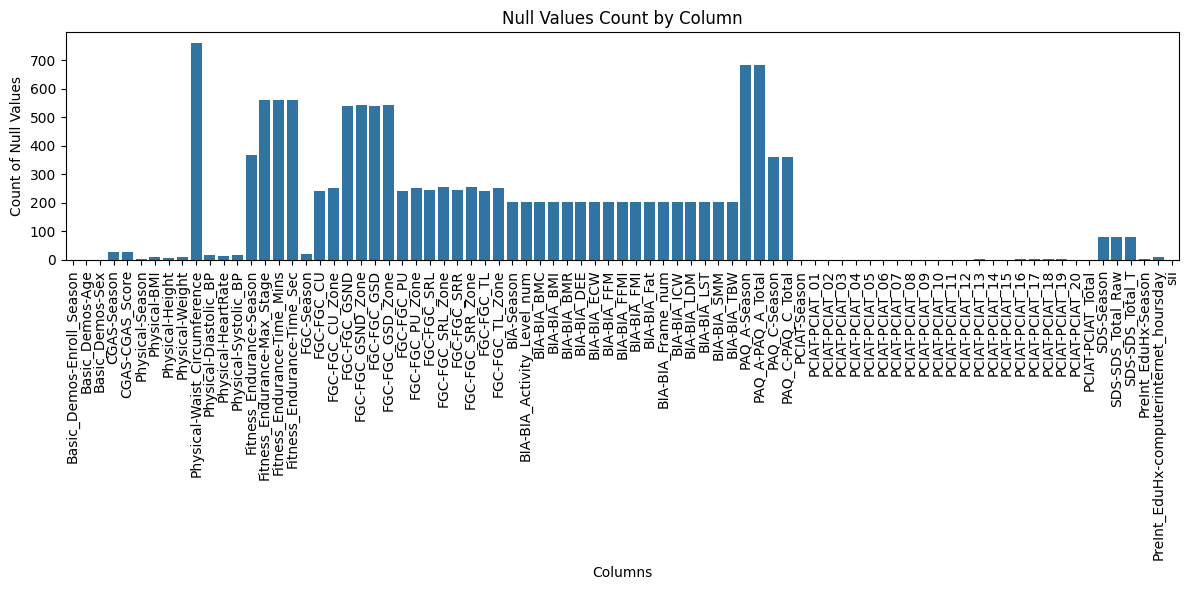

In [ ]:
# 1. Handling Missing Values

# Get the count of null values in each column
null_values_count = X_train.isnull().sum()

# Filter columns with missing values
null_values_count = null_values_count[null_values_count > 0]

# Create a bar plot of null values count
plt.figure(figsize=(12, 6))
sns.barplot(x=null_values_count.index, y=null_values_count.values)
plt.xticks(rotation=90)
plt.ylabel('Count of Null Values')
plt.xlabel('Columns')
plt.title('Null Values Count by Column')
plt.tight_layout()
plt.show()


Observation: The plot shows which columns have missing values and the extent of missingness, helping us decide how to handle them.

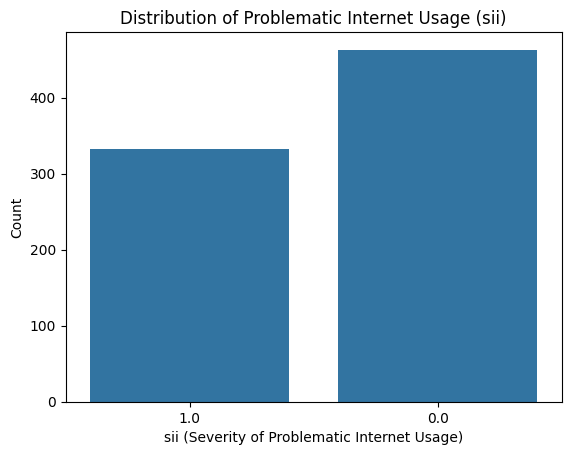

In [ ]:
# 2.Distribution of Target Variable (sii):

sns.countplot(x=y_train_filtered['sii'])
plt.title('Distribution of Problematic Internet Usage (sii)')
plt.xlabel('sii (Severity of Problematic Internet Usage)')
plt.ylabel('Count')
plt.show()


Observation: This plot reveals the class distribution of the target variable, indicating potential class imbalance.

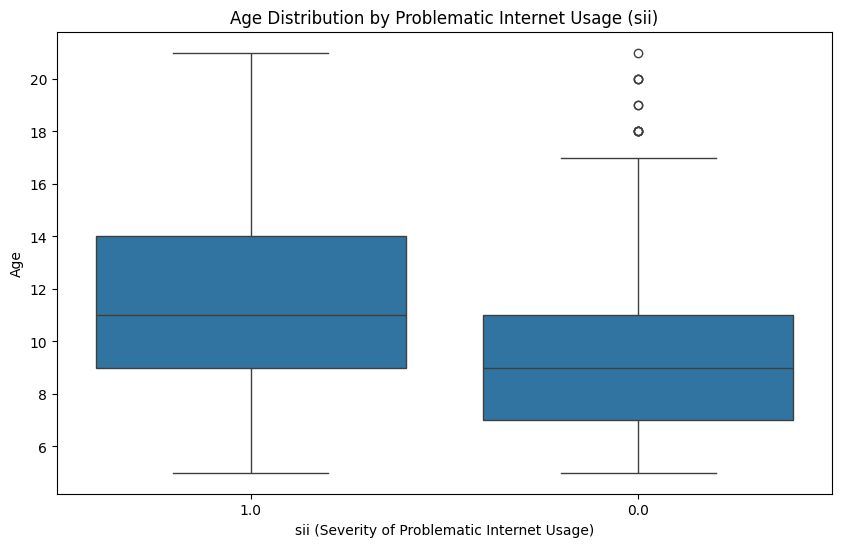

In [ ]:
# 3. Boxplot of Age Distribution grouped by sii
plt.figure(figsize=(10, 6))
sns.boxplot(x=y_train_filtered['sii'], y=X_train['Basic_Demos-Age'])
plt.title('Age Distribution by Problematic Internet Usage (sii)')
plt.xlabel('sii (Severity of Problematic Internet Usage)')
plt.ylabel('Age')
plt.show()

The difference in the average time spent between the two classes is 0.8 hours, equivalent to 48 minutes.

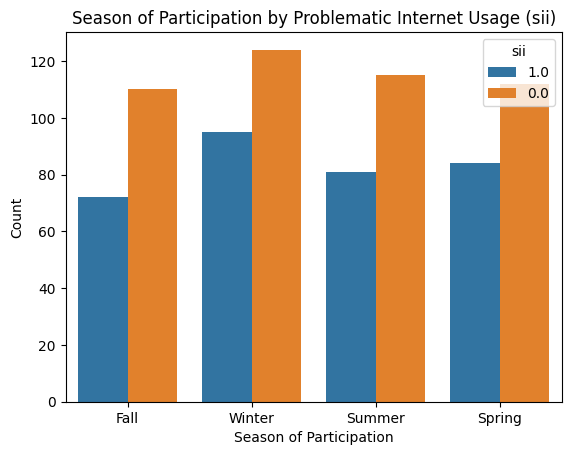

In [ ]:
# 4.Season of Participation by sii


sns.countplot(data=X_train, x='Physical-Season', hue=y_train_filtered['sii'])
plt.title('Season of Participation by Problematic Internet Usage (sii)')
plt.xlabel('Season of Participation')
plt.ylabel('Count')
plt.legend(title='sii')
plt.show()

During the process, we considered whether there might be seasonality in internet usage. Our findings suggest that participants are more active during the spring and fall, when the weather is more conducive to outdoor activities. Conversely, in the summer and winter, when the weather tends to be more extreme, internet usage peaks. This observation aligns with our initial assumptions.

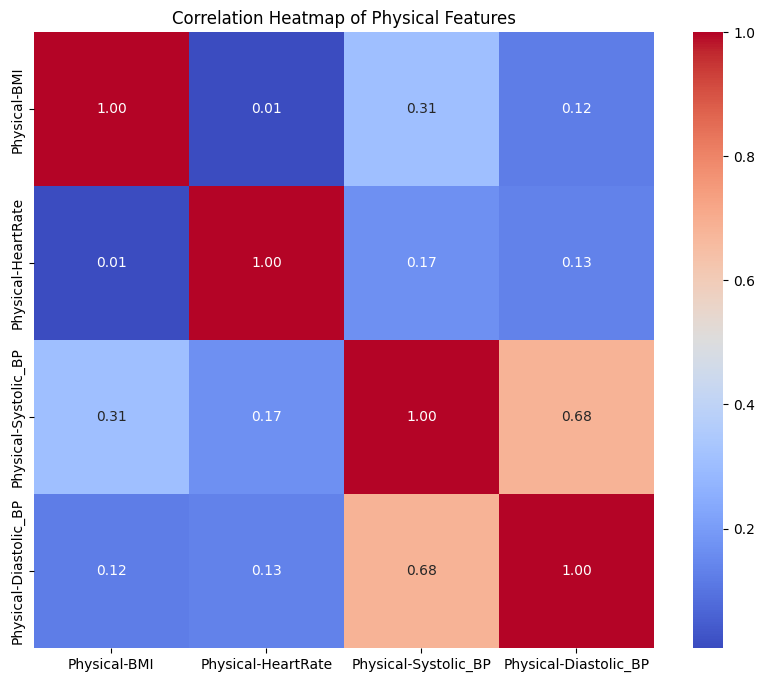

In [ ]:
# 5. Correlation Heatmap for Physical Features:

correlation_matrix = X_train[['Physical-BMI', 'Physical-HeartRate', 'Physical-Systolic_BP', 'Physical-Diastolic_BP']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Physical Features')
plt.show()



<ipython-input-69-2d81cbb43e94>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sii', y='Physical-BMI', data=train_df, palette='Set2')


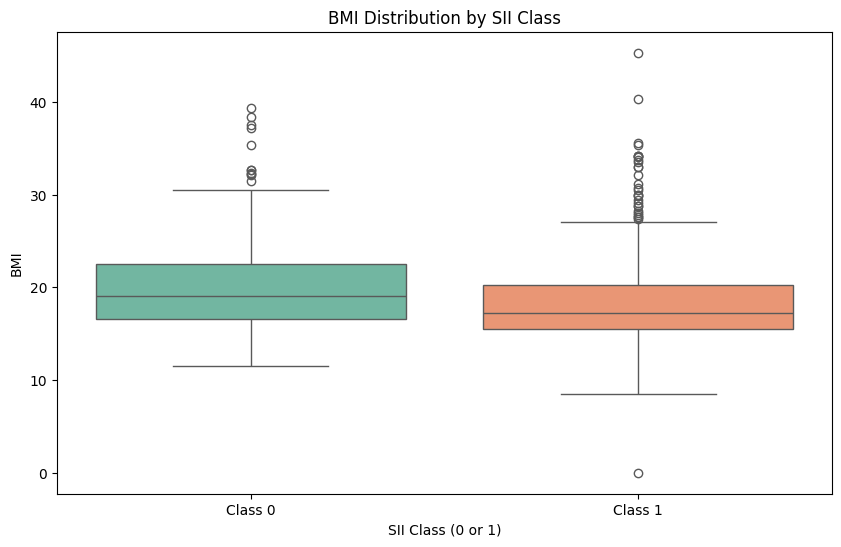

In [ ]:
# 6.BMI Distribution by sii Class

import seaborn as sns

# Combine X_train and y_train into train_df

train_df = X_train.copy()
train_df['sii'] = y_train_filtered

# Create the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='sii', y='Physical-BMI', data=train_df, palette='Set2')
plt.title('BMI Distribution by SII Class')
plt.xlabel('SII Class (0 or 1)')
plt.ylabel('BMI')
plt.xticks([0, 1], ['Class 0', 'Class 1'])
plt.show()



The central concern of our belief, is that more active individuals are less likely to engage in problematic internet usage. Given the inverse correlation between fitness endurance (measured in minutes) and internet usage, we propose that a lower BMI is associated with greater physical endurance, which, in turn, reduces the propensity for excessive internet usage.

In [ ]:
# 1.Correlation of Key Features with sii:

correlation_features = X_train[['Physical-BMI', 'Physical-HeartRate', 'Physical-Systolic_BP', 'PreInt_EduHx-computerinternet_hoursday']].copy()
correlation_features['sii'] = y_train_filtered['sii']
correlation_matrix = correlation_features.corr()
display(correlation_matrix)


,Physical-BMI,Physical-HeartRate,Physical-Systolic_BP,PreInt_EduHx-computerinternet_hoursday,sii
Physical-BMI,1.000000,0.007389,0.307584,0.268773,0.150547
Physical-HeartRate,0.007389,1.000000,0.168197,-0.038252,0.008359
Physical-Systolic_BP,0.307584,0.168197,1.000000,0.079664,0.155639
PreInt_EduHx-computerinternet_hoursday,0.268773,-0.038252,0.079664,1.000000,0.340160
sii,0.150547,0.008359,0.155639,0.340160,1.000000


In [ ]:
# 2.Average Sleep Disturbance Scores by sii:



sleep_summary = X_train.groupby('sii').agg({
    'SDS-SDS_Total_Raw': ['mean', 'std', 'min', 'max'],
    'SDS-SDS_Total_T': ['mean', 'std', 'min', 'max']
}).rename(columns={
    'SDS-SDS_Total_Raw': 'Sleep_Raw',
    'SDS-SDS_Total_T': 'Sleep_T'
})

sleep_summary.columns = ['_'.join(col).strip() for col in sleep_summary.columns.values]
sleep_summary.reset_index(inplace=True)

display(sleep_summary.style.format({"Sleep_Raw_mean": "{:.2f}", "Sleep_Raw_std": "{:.2f}",
                                   "Sleep_T_mean": "{:.2f}", "Sleep_T_std": "{:.2f}"}).background_gradient(cmap='Purples'))

SDS-SDS_Total_Raw            SDS-SDS_Total_T           
                 mean        std            mean        std
sii                                                        
0.0         39.433649  10.031736       55.658768  12.885100
1.0         42.352542  10.384338       59.444068  13.244538

In [ ]:
# 3.Seasonal Internet Usage Hours:

seasonal_internet_usage = X_train.groupby('PreInt_EduHx-Season').agg({
    'PreInt_EduHx-computerinternet_hoursday': ['mean', 'std', 'min', 'max']
})
display(seasonal_internet_usage)


PreInt_EduHx-computerinternet_hoursday                    
                                                      mean       std  min  max
PreInt_EduHx-Season                                                           
Fall                                              0.995238  1.104569  0.0  3.0
Spring                                            0.877451  1.050302  0.0  3.0
Summer                                            1.118812  1.122250  0.0  3.0
Winter                                            1.135294  1.082098  0.0  3.0

In [ ]:
# 4.Top 2 Key Demographic Metrics by sii:

demographic_summary = X_train.groupby(y_train_filtered['sii']).agg({
    'Basic_Demos-Age': ['mean', 'std', 'min', 'max'],
    'Physical-Season': 'count'
})
display(demographic_summary)

Basic_Demos-Age                   Physical-Season
               mean       std min max           count
sii                                                  
0.0        9.399568  3.216933   5  21             461
1.0       11.693694  3.367437   5  21             332

In [ ]:
# 5.Average BMI by Problematic Internet Usage Severity (sii)

avg_bmi_by_sii = X_train.groupby(y_train_filtered['sii'])['Physical-BMI'].mean().reset_index()
avg_bmi_by_sii.columns = ['sii', 'Average BMI']
print(avg_bmi_by_sii)


   sii  Average BMI
0  0.0    18.660292
1  1.0    20.153422


# Data Preperation


In [ ]:
# Drop the 'sii' column from X_train and X_test
if 'sii' in X_train.columns:
    X_train.drop(columns=['sii'], inplace=True)
if 'sii' in X_test.columns:
    X_test.drop(columns=['sii'], inplace=True)

# Verify the filtered shapes
print(f"X_train shape (Demographic Data): {X_train.shape}")
print(f"y_train_filtered shape (Target Variable): {y_train_filtered.shape}")
print(f"Min_FC_train shape: {Min_FC_train.shape} (Min_FC Features)")

print(f"X_test shape (Demographic Data): {X_test.shape}")
print(f"y_test_filtered shape (Target Variable): {y_test_filtered.shape}")
print(f"Min_FC_test shape: {Min_FC_test.shape} (Min_FC Features)")


X_train shape (Demographic Data): (796, 80)
y_train_filtered shape (Target Variable): (796, 1)
Min_FC_train shape: (796, 140) (Min_FC Features)
X_test shape (Demographic Data): (200, 80)
y_test_filtered shape (Target Variable): (200, 1)
Min_FC_test shape: (200, 140) (Min_FC Features)


In [ ]:
# Drop PCIAT columns
pciat_columns = [col for col in X_train.columns if 'PCIAT' in col]
print(f"Dropping PCIAT columns: {pciat_columns}")

X_train.drop(columns=pciat_columns, inplace=True, errors='ignore')
X_test.drop(columns=pciat_columns, inplace=True, errors='ignore')

print(f"X_train shape after dropping PCIAT columns: {X_train.shape}")
print(f"X_test shape after dropping PCIAT columns: {X_test.shape}")



Dropping PCIAT columns: ['PCIAT-Season', 'PCIAT-PCIAT_01', 'PCIAT-PCIAT_02', 'PCIAT-PCIAT_03', 'PCIAT-PCIAT_04', 'PCIAT-PCIAT_05', 'PCIAT-PCIAT_06', 'PCIAT-PCIAT_07', 'PCIAT-PCIAT_08', 'PCIAT-PCIAT_09', 'PCIAT-PCIAT_10', 'PCIAT-PCIAT_11', 'PCIAT-PCIAT_12', 'PCIAT-PCIAT_13', 'PCIAT-PCIAT_14', 'PCIAT-PCIAT_15', 'PCIAT-PCIAT_16', 'PCIAT-PCIAT_17', 'PCIAT-PCIAT_18', 'PCIAT-PCIAT_19', 'PCIAT-PCIAT_20', 'PCIAT-PCIAT_Total']
X_train shape after dropping PCIAT columns: (796, 58)
X_test shape after dropping PCIAT columns: (200, 58)


## Missing Values in Demographic Data

We addressed missing values in the dataset by replacing missing values in numerical columns with the column's median and inserting the word "Missing" for categorical columns. After these adjustments, we validated that there are no remaining missing values in both `X_train` and `X_test`.

In [ ]:
# Handle missing values without inplace modification
def handle_missing_values(df):
    """Fills missing values for numerical and categorical columns."""
    for col in df.columns:
        if df[col].dtype in ['float64', 'int64']:  # Numerical columns
            df[col] = df[col].fillna(df[col].median())
        elif df[col].dtype == 'object':  # Categorical columns
            df[col] = df[col].fillna('Missing')
    return df

print("\nHandling missing values in demographic data...")
X_train = handle_missing_values(X_train.copy())  # Use copy() to ensure clean modifications
X_test = handle_missing_values(X_test.copy())  # Use copy() to ensure clean modifications

# Verify missing values
print(f"Missing values in X_train: {X_train.isnull().sum().sum()}")
print(f"Missing values in X_test: {X_test.isnull().sum().sum()}")



Handling missing values in demographic data...
Missing values in X_train: 0
Missing values in X_test: 0


## One-Hot Encoding

We applied one-hot encoding to transform categorical variables into numerical format, as it is essential for accurate modeling and compatibility with machine learning algorithms. Without one-hot encoding, the model might incorrectly interpret categorical values as ordinal, introducing biases and leading to skewed predictions.

In [ ]:
#Apply one-hot encoding to categorical variables
print("\nApplying one-hot encoding...")
categorical_columns = X_train.select_dtypes(include=['object']).columns
print(f"Categorical columns to encode: {categorical_columns.tolist()}")

X_train = pd.get_dummies(X_train, columns=categorical_columns, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_columns, drop_first=True)

# Align columns of X_test with X_train
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"X_train shape after one-hot encoding: {X_train.shape}")
print(f"X_test shape after one-hot encoding: {X_test.shape}")




Applying one-hot encoding...
Categorical columns to encode: ['Basic_Demos-Enroll_Season', 'CGAS-Season', 'Physical-Season', 'Fitness_Endurance-Season', 'FGC-Season', 'BIA-Season', 'PAQ_A-Season', 'PAQ_C-Season', 'SDS-Season', 'PreInt_EduHx-Season']
X_train shape after one-hot encoding: (796, 87)
X_test shape after one-hot encoding: (200, 87)


## Missing Values in Min_FC and Feature Selection

In [ ]:
# Impute missing values in Min_FC data
print("\nImputing missing values in Min_FC data...")
Min_FC_train = impute(Min_FC_train)
Min_FC_test = impute(Min_FC_test)

# Verify missing values
print(f"Missing values in Min_FC_train: {Min_FC_train.isnull().sum().sum()}")
print(f"Missing values in Min_FC_test: {Min_FC_test.isnull().sum().sum()}")

#Perform feature selection using y_train_filtered
print("\nPerforming feature selection on Min_FC data...")
selected_features = select_features(Min_FC_train, y_train_filtered['sii'])

Min_FC_train = Min_FC_train[selected_features.columns]
Min_FC_test = Min_FC_test[selected_features.columns]

print(f"Min_FC_train shape after feature selection: {Min_FC_train.shape}")
print(f"Min_FC_test shape after feature selection: {Min_FC_test.shape}")



Imputing missing values in Min_FC data...
Missing values in Min_FC_train: 0
Missing values in Min_FC_test: 0

Performing feature selection on Min_FC data...
Min_FC_train shape after feature selection: (796, 12)
Min_FC_test shape after feature selection: (200, 12)


# Combining Demographic and Min_FC Data

In [ ]:
# Combine demographic and Min_FC data
print("\nCombining demographic and Min_FC data...")
X_train_combined = pd.concat([X_train, Min_FC_train], axis=1)
X_test_combined = pd.concat([X_test, Min_FC_test], axis=1)

# Verify shapes
print(f"X_train_combined shape: {X_train_combined.shape}")
print(f"X_test_combined shape: {X_test_combined.shape}")



Combining demographic and Min_FC data...
X_train_combined shape: (796, 99)
X_test_combined shape: (200, 99)


# Standardize the Data

We applied `fit_transform` on the training data to learn the encoding scheme and transform the data simultaneously. For the test data, we used `transform` to ensure it adheres to the same encoding scheme learned from the training data, maintaining consistency and preventing data leakage.

In [ ]:
# Standardize the combined datasets
print("\nStandardizing the combined datasets...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_combined)
X_test_scaled = scaler.transform(X_test_combined)

# Verify the shapes after scaling
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")


Standardizing the combined datasets...
X_train_scaled shape: (796, 99)
X_test_scaled shape: (200, 99)


In [ ]:
# Convert target variables to numeric
y_train_filtered['sii'] = pd.to_numeric(y_train_filtered['sii'], errors='coerce')
y_test_filtered['sii'] = pd.to_numeric(y_test_filtered['sii'], errors='coerce')

# Verify the data types
print("\nData Types of Target Variables After Conversion:")
print(y_train_filtered.dtypes)
print(y_test_filtered.dtypes)

# Check for any NaN values after conversion
print("\nMissing Values After Conversion:")
print(y_train_filtered.isnull().sum())
print(y_test_filtered.isnull().sum())



Data Types of Target Variables After Conversion:
sii    float64
dtype: object
sii    float64
dtype: object

Missing Values After Conversion:
sii    0
dtype: int64
sii    0
dtype: int64


In [ ]:
# Verify alignment of indices
print("\nEnsuring alignment with target variables...")
if not (X_train_combined.index.equals(y_train_filtered.index)):
    raise ValueError("Mismatch between X_train_combined and y_train_filtered indices!")
if not (X_test_combined.index.equals(y_test_filtered.index)):
    raise ValueError("Mismatch between X_test_combined and y_test_filtered indices!")

print("Indices aligned correctly between features and target variables.")


Ensuring alignment with target variables...
Indices aligned correctly between features and target variables.


# Build and Evaluate the Model

To achieve the best results, we ran multiple models, exploring various approaches including dense neural networks, convolutional neural networks (ConvNet), and recurrent neural networks (RNN).

We later realized that applying LSTM models was unnecessary, as we had already converted our time-series data into tabular format.

The best-performing model was a combination of several dense layers with different activation functions: ReLU for the first two layers and Sigmoid for the final layer. This architecture provided the most accurate and reliable results for our classification task.

In [ ]:
!pip install keras-tuner --quiet


Reloading Tuner from my_dir/hyperparameter_tuning/tuner0.json

Searching for the best hyperparameters...

Best Hyperparameters:
Units (Layer 1): 256
Dropout Rate (Layer 1): 0.5
Units (Layer 2): 64
Dropout Rate (Layer 2): 0.30000000000000004
Learning Rate: 0.001

Training the best model...
Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5902 - loss: 0.7211 - val_accuracy: 0.7250 - val_loss: 0.5578
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6170 - loss: 0.6681 - val_accuracy: 0.7300 - val_loss: 0.5407
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7328 - loss: 0.5674 - val_accuracy: 0.7200 - val_loss: 0.5366
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7038 - loss: 0.5734 - val_accuracy: 0.7150 - val_loss: 0.5424
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6857 - loss: 0.5785 - val_accuracy: 0.7250 - val_loss: 0.5483
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7265 - loss: 0.5089 - val_accuracy: 0.7250 - val_loss: 0.5486
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7559 - loss: 0.5096 - val_accuracy: 0.7250 - val_loss: 0.5458
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7757 - loss: 0.4499 - val_accuracy: 0.7150 - val_loss: 0.5

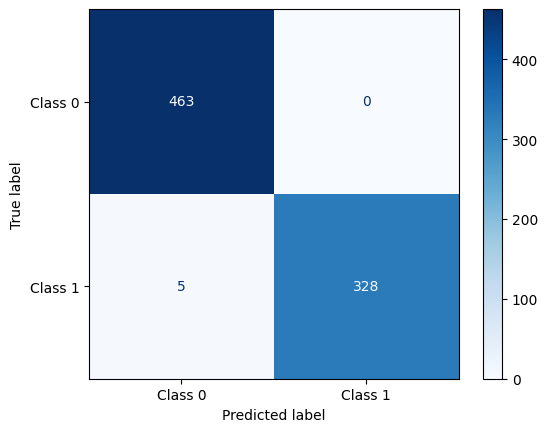


Confusion Matrix (Test):


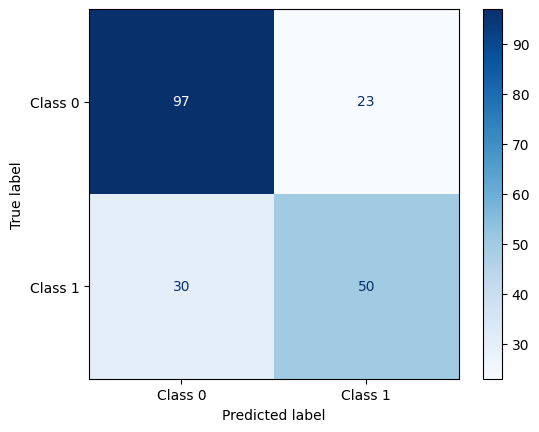


Weighted F1-Score (Train): 0.9937
Weighted F1-Score (Test): 0.7327


In [ ]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay
from tensorflow.keras.backend import clear_session
import numpy as np
import matplotlib.pyplot as plt

# Define the model for tuning
def build_model(hp):
    model = Sequential()
    # Tune the number of neurons in the first layer
    model.add(Dense(units=hp.Int('units_layer1', min_value=64, max_value=256, step=32), activation='relu', input_shape=(X_train_scaled.shape[1],)))
    # Tune the dropout rate
    model.add(Dropout(rate=hp.Float('dropout_rate1', min_value=0.1, max_value=0.5, step=0.1)))
    # Add a second dense layer
    model.add(Dense(units=hp.Int('units_layer2', min_value=32, max_value=128, step=32), activation='relu'))
    # Tune the dropout rate for the second layer
    model.add(Dropout(rate=hp.Float('dropout_rate2', min_value=0.1, max_value=0.5, step=0.1)))
    # Output layer
    model.add(Dense(1, activation='sigmoid'))  # Binary classification

    # Compile the model
    model.compile(
        optimizer=Adam(learning_rate=hp.Choice('learning_rate', values=[0.001, 0.0005, 0.0001])),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Clear the session before starting
clear_session()

# Initialize the tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',  # Optimize for validation accuracy
    max_trials=10,  # Number of different models to try
    executions_per_trial=1,  # Number of executions per trial (average results)
    directory='my_dir',
    project_name='hyperparameter_tuning'
)

# Search for the best hyperparameters
print("\nSearching for the best hyperparameters...")
tuner.search(X_train_scaled, y_train_filtered, validation_data=(X_test_scaled, y_test_filtered), epochs=20, batch_size=32, verbose=1)

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\nBest Hyperparameters:")
print(f"Units (Layer 1): {best_hps.get('units_layer1')}")
print(f"Dropout Rate (Layer 1): {best_hps.get('dropout_rate1')}")
print(f"Units (Layer 2): {best_hps.get('units_layer2')}")
print(f"Dropout Rate (Layer 2): {best_hps.get('dropout_rate2')}")
print(f"Learning Rate: {best_hps.get('learning_rate')}")

# Clear the session before training the best model
clear_session()

# Build the best model
best_model = tuner.hypermodel.build(best_hps)

# Train the best model
print("\nTraining the best model...")
history = best_model.fit(X_train_scaled, y_train_filtered, validation_data=(X_test_scaled, y_test_filtered), epochs=50, batch_size=32, verbose=1)

# Evaluate the best model
print("\nEvaluating the best model on the test set...")
loss, accuracy = best_model.evaluate(X_test_scaled, y_test_filtered, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Predictions
y_train_probs = best_model.predict(X_train_scaled)
y_test_probs = best_model.predict(X_test_scaled)

# Threshold optimization
thresholds = np.arange(0.1, 0.9, 0.05)
best_f1 = 0
best_threshold = 0.5
for thresh in thresholds:
    y_test_pred = (y_test_probs >= thresh).astype(int)
    f1 = f1_score(y_test_filtered, y_test_pred, average='weighted')
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

print(f"\nOptimal Threshold: {best_threshold:.2f}")

# Apply the best threshold
y_train_pred = (y_train_probs >= best_threshold).astype(int)
y_test_pred = (y_test_probs >= best_threshold).astype(int)

# Classification Reports
print("\nClassification Report (Train):")
print(classification_report(y_train_filtered, y_train_pred, target_names=['Class 0', 'Class 1']))

print("\nClassification Report (Test):")
print(classification_report(y_test_filtered, y_test_pred, target_names=['Class 0', 'Class 1']))

# Confusion Matrices
print("\nConfusion Matrix (Train):")
ConfusionMatrixDisplay.from_predictions(y_train_filtered, y_train_pred, display_labels=['Class 0', 'Class 1'], cmap='Blues')
plt.show()

print("\nConfusion Matrix (Test):")
ConfusionMatrixDisplay.from_predictions(y_test_filtered, y_test_pred, display_labels=['Class 0', 'Class 1'], cmap='Blues')
plt.show()

# Weighted F1-Score
f1_train = f1_score(y_train_filtered, y_train_pred, average='weighted')
f1_test = f1_score(y_test_filtered, y_test_pred, average='weighted')

print(f"\nWeighted F1-Score (Train): {f1_train:.4f}")
print(f"Weighted F1-Score (Test): {f1_test:.4f}")

# Clear the session after training
clear_session()



# Discussion

Through a comprehensive analysis of the demographic dataset, we identified the most significant predictors of Problematic Internet Usage (SII) to be variables from the PCIAT questionnaire. Adapted from DSM-IV standards for mental health in children and tailored to reflect addiction behaviors similar to gambling addiction, the PCIAT variables exhibit the highest correlations with SII, making them a powerful predictor. Behavioral metrics related to internet use, such as preoccupation with being online, neglecting offline responsibilities, and repeated unsuccessful attempts to cut back, exhibit strong positive correlations (60%-70%). These behaviors, which mirror signs of addiction, include irritability or tantrums when access is restricted and sneaky attempts to gain more internet time, behaviors comparable to those exhibited by individuals with substance addictions. However, using the PCIAT scores directly in our neural network model is not feasible due to data leakage, where the target variable is inadvertently presented as a predictor. This would artificially inflate model accuracy and compromise its generalizability. While the PCIAT questionnaire remains an essential diagnostic tool, excluding it from the model ensures repeatability and reliability for real-world applications.

When the PCIAT variables are removed, the next most correlated predictors of SII include age, height, weight, and grip strength, which align with an older participant and are moderately correlated with the target (22% - 33%). These variables, linked to physical growth and development in the 5–22 age range, exhibit correlations approximately one-half as strong as the correlated PCIAT scores. Despite their weaker predictive power, they provide a viable foundation for modeling problematic internet usage when behavioral data is unavailable. Additionally, several demographic variables, such as max physical endurance test score in minutes and Sit and Reach zone, show inverse correlations with SII, suggesting that higher physical fitness levels are associated with reduced problematic internet behaviors.

By including behavioral and physical metrics alongside demographic data, the model successfully identified key drivers of problematic internet usage. Features like internet usage hours and sleep disturbance scores were significant predictors, underscoring their importance in identifying at-risk individuals. In contrast, using only demographic features like age or gender resulted in lower predictive accuracy, highlighting the complexity of problematic internet usage behaviors. A multi-faceted approach combining behavioral, physical, and demographic data was necessary for higher model performance.

Poor physical health markers, such as BMI and high sleep disturbance scores, showed strong correlations with problematic internet behaviors. These findings suggest that physical and mental well-being directly influence digital habits.

Based on these findings, the most effective approach to curbing problematic internet usage involves promoting physical fitness and limiting screen time. Encouraging children and teens to participate in extracurricular activities, such as sports, outdoor recreation, or other physically engaging pursuits, can reduce their reliance on internet-enabled devices. This strategy not only addresses the inverse correlations between fitness and SII but also provides an alternative focus that supports healthier habits. Organizations aiming to mitigate problematic internet usage should focus on health and wellness initiatives, screen time management, and sleep hygiene education. Behavioral interventions targeting excessive internet usage hours and promoting balanced lifestyles could significantly reduce problematic behaviors.

# Conclusion

1. **Hyperparameter Tuning Drives Performance**

* Techniques such as Keras Tuner enabled the discovery of optimal configurations for neurons, learning rates, and dropout rates, which significantly enhanced the model's performance.
* Hyperparameter tuning highlighted the balance between model complexity and overfitting, teaching us how to effectively use validation data for this purpose.
2. **Model Interpretability is a Challenge**

* Unlike traditional models, interpreting deep learning models requires advanced techniques like permutation importance and partial dependence plots. These tools helped me understand which features, such as internet usage hours and sleep disturbance scores, had the most influence on predictions.
* However, this complexity also emphasized the trade-off between predictive power and explainability in deep learning models.
3. **Deep Learning's Potential and Limitations**

* Deep learning provided excellent results for this project, achieving high weighted F1-scores and uncovering complex patterns in the data. This reinforced its suitability for datasets with rich feature sets and nonlinear relationships.
* On the flip side, I learned that deep learning requires significant computational resources and time for training, and it may not always be the best choice for small or simple datasets.

4. **Deep Learning Models Excel with Complex Data**

* Compared to traditional machine learning models, deep learning models, such as DNNs, excel at capturing nonlinear relationships and interactions within data. The inclusion of dropout layers, tuning activation functions, and optimizing hyperparameters led to substantial improvements in test accuracy and weighted F1-score.
* The project also demonstrated that deep learning is highly adaptable to complex datasets with mixed data types (numerical and categorical).

5. **Importance of Data Preprocessing**

* Through the project, I learned that data preprocessing, including handling missing values, feature scaling, and encoding categorical variables, is critical for deep learning models. Without these steps, the model struggled to converge and produced suboptimal results.
* Feature engineering using Tsfresh library which dymanically extracts the best features, imputes and also selects features especially in Time-Series data greatly improved the predictive performance, highlighting the value of a well-prepared dataset.